In [1]:
print("Yes")

Yes


In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [39]:
def fetch_and_prepare_data(number):
    # fetching data from the UCL repository
    url= "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
    try:
        df=pd.read_excel(url)
        print(f"{len(df)} transactions.")
    except Exception as e:
        print(f"Error: {e}")
        return None

    df = df.dropna(subset=["StockCode", "Description", 'Quantity'])
    df= df[df["Quantity"]>0]
    df["InvoiceDate"]= pd.to_datetime(df["InvoiceDate"])


    # Transforming into an FMCG Simulation

    top_products=df["StockCode"].value_counts().index
    target_skus=top_products[:number] # frequent item 

    product_df= df[df["StockCode"].isin(target_skus)].copy()
    daily_sales = product_df.groupby([product_df["InvoiceDate"].dt.date, "Country","StockCode"])["Quantity"].sum().reset_index()
    daily_sales.columns = ["Date", "Region", "StockCode", "Units_Sold"]
    daily_sales["Date"]=pd.to_datetime(daily_sales["Date"])

    

    # Data sorting
    daily_sales= daily_sales.sort_values(by=["Region", "StockCode","Date"]).reset_index(drop=True)

    # Base assumption is that the region baseline stock capacity of 1000 and try to track sales deplete that the stock over time

    capacity=1000
    reorder_threshold=200
    simulated_records = []

    for (region, stock_code), group in daily_sales.groupby(["Region","StockCode"]):
        current_stock=capacity
        for idx, row in group.iterrows():
            units_sold=row["Units_Sold"]
            current_stock -= units_sold

            if current_stock < 0:
                current_stock=0

            reorder_triggered = 1 if current_stock <= reorder_threshold else 0

            simulated_records.append({
                "Date": row["Date"],
                "Region": region,
                "StockCode": stock_code,
                "Units_Sold": units_sold,
                "Current_Stock": current_stock,
                "Reorder_Triggered": reorder_triggered
            })

            if reorder_triggered == 1:
                current_stock = capacity

    sandbox_fmcg_df = pd.DataFrame(simulated_records)

    print(f" Engineered {len(sandbox_fmcg_df)} clean history")
    return sandbox_fmcg_df
if __name__ == "__main__":
    fmcg_data= fetch_and_prepare_data(50)

    if fmcg_data is not None:
        print(f"Processed Supply Chain Features {fmcg_data.head(15)}")

        fmcg_data.to_csv(r"Sandbox_fmcg_pipeline.csv", index=False)
        print(f"Saved the data {len(fmcg_data)} rows")

541909 transactions.
 Engineered 18075 clean history
Processed Supply Chain Features          Date     Region StockCode  Units_Sold  Current_Stock  \
0  2010-12-17  Australia     20725          10            990   
1  2011-04-08  Australia     20725          30            960   
2  2011-06-15  Australia     20725         100            860   
3  2011-07-19  Australia     20725          21            839   
4  2011-08-12  Australia     20725          10            829   
5  2011-09-28  Australia     20725          10            819   
6  2011-11-15  Australia     20725         100            719   
7  2011-01-11  Australia     20726          20            980   
8  2011-02-15  Australia     20726         100            880   
9  2011-04-08  Australia     20726          10            870   
10 2011-08-12  Australia     20726          10            860   
11 2011-08-18  Australia     20726         100            760   
12 2011-09-28  Australia     20726          30            730   
13 20

### EDA

In [18]:
df_raw=pd.read_excel("https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx")

In [5]:
df_raw.info()
df_raw.describe()

print("Missing Values: ",df_raw.isnull().sum())

negative_quantities = df_raw[df_raw['Quantity'] < 0]
print(f"Number of cancelled/returned transactions: {len(negative_quantities)}")

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB
Missing Values:  InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Number of cancelled/returned transactions: 10624


In [6]:
df.shape

NameError: name 'df' is not defined

C:\Users\Admin\AppData\Local\Temp\ipykernel_10360\1360911003.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.index.astype(str), y=top_items.values,palette="viridis")


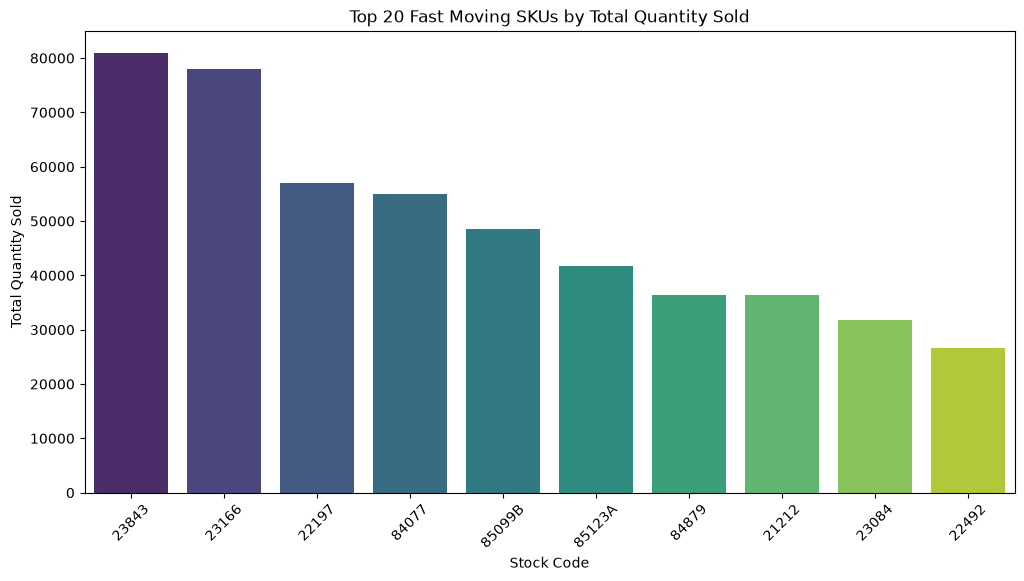

In [21]:
top_items = df_raw[df_raw['Quantity'] > 0].groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_items.index.astype(str), y=top_items.values,palette="viridis")

plt.title("Top 20 Fast Moving SKUs by Total Quantity Sold")
plt.xlabel("Stock Code")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.show()

In [24]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
 8   DateOnly     541909 non-null  object        
dtypes: datetime64[us](1), float64(2), int64(1), object(4), str(1)
memory usage: 37.2+ MB


In [23]:
df_raw.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [10]:
print("Missing values: " ,df.isnull().sum())

negative_quantities=df[df["Units_Sold"]<0]
print(f"Cancelled/ Returned transactions: {len(negative_quantities)}")

Missing values:  Date                 0
Region               0
Units_Sold           0
Current_Stock        0
Reorder_Triggered    0
dtype: int64
Cancelled/ Returned transactions: 0


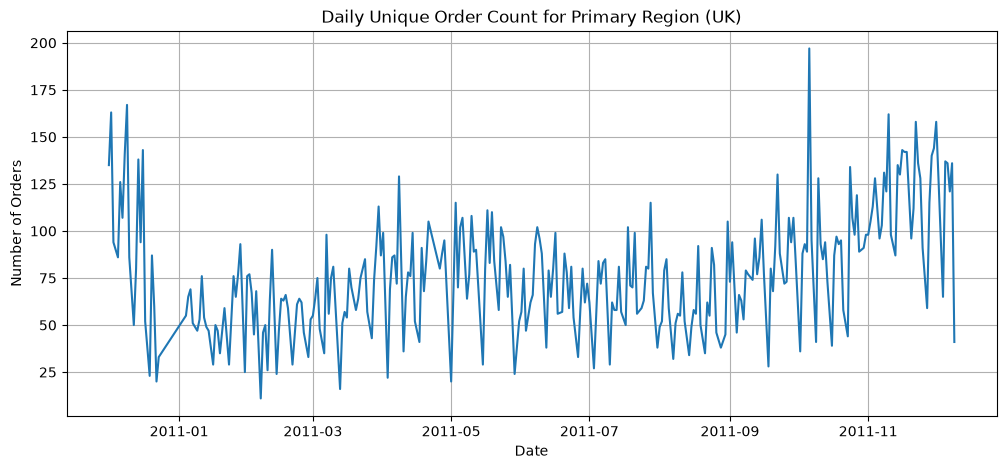

In [20]:
df_raw["InvoiceDate"]=pd.to_datetime(df_raw["InvoiceDate"])
df_raw["DateOnly"]= df_raw["InvoiceDate"].dt.date

uk_daily_orders=df_raw[df_raw["Country"]== "United Kingdom"].groupby("DateOnly")["InvoiceNo"].nunique()

plt.figure(figsize=(12,5))
uk_daily_orders.plot(kind="line")
plt.title("Daily Unique Order Count for Primary Region (UK)")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.grid(True)
plt.show()

###### Invoice numbers starting with 'C' (negative quantities) represents 10,624 rows or roughly 1.96% of the total dataset. so this are returns.They will be filtered out before building the inventory drawdown simulation to avoid artificially inflate our stock levels

##### Macro Seasonality
###### The daily unique order count time-series confirms a massive spike in order velocity beginning in October and peaking in Novemver/ December . we must account for this seasonal phenomena

###### There are 135,080 missing values , however due to the goal of macro spatial demand forecasting ,we drop the customer ID column as it is not going to be that useful

##### Target Variable Selection
###### Stock code 23843 is the absolute highest-velocity SKU(over 80,000 Units sold).We Isolate the SKU to act as our baseline proxy for a fast-moving beverage product in the simulation

In [41]:
def train_fmcg_demand_model(model,new_data=None):

    # loading_data
    if new_data is None :
        df= pd.read_csv("Sandbox_fmcg_pipeline.csv")
        
        # print(f"Loaded {len(df)} rows for modeling.")
    else:
        df=new_data
    df["Date"]=pd.to_datetime(df["Date"])
    
    # I am creating Lag and Rolling features per Region

    df["Sales_Lag_1"]=df.groupby(["Region","StockCode"])["Units_Sold"].shift(1)
    df["Sales_Lag_2"]=df.groupby(["Region", "StockCode"])["Units_Sold"].shift(2)

    # Rolling average of units sold
    df["Sales_Rolling_Mean_3"]=df.groupby(["Region","StockCode"])["Units_Sold"].transform(lambda x: x.shift(1).rolling(window=3).mean())

    # adding the yesterday's closing stock! trying to solve the Blind Warehouse Problem 
    df["Stock_Lag_1"]= df.groupby(["Region","StockCode"])["Current_Stock"].shift(1)

    df=df.dropna().reset_index(drop=True)

    feature_cols=["Units_Sold","Sales_Lag_1","Sales_Lag_2",'Sales_Rolling_Mean_3', "Stock_Lag_1"]

    X=df[feature_cols]
    y=df['Reorder_Triggered']

    df=df.sort_values("Date")
    split_idx=int(len(df) * 0.8)

    X_train,X_test=X.iloc[:split_idx],X.iloc[split_idx:]
    y_train,y_test= y.iloc[:split_idx],y.iloc[split_idx:]

    print(f"Training set size: {len(X_train)} | Test set size: {len(X_test)}")

    # Training the predictive model
    model.fit(X_train,y_train)


    y_pred=model.predict(X_test)
    print(f"EVALUATION : {classification_report(y_test,y_pred)}")


    importances = model.feature_importances_
    for name, importance in zip(feature_cols, importances):
        print(f"{name}: {importance:.4f}")

    return model



In [42]:
if __name__ == "__main__":
    rfc=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
    trained_model=train_fmcg_demand_model(model=rfc)

Training set size: 13029 | Test set size: 3258
EVALUATION :               precision    recall  f1-score   support

           0       0.99      0.99      0.99      3008
           1       0.93      0.94      0.93       250

    accuracy                           0.99      3258
   macro avg       0.96      0.97      0.96      3258
weighted avg       0.99      0.99      0.99      3258

Units_Sold: 0.3235
Sales_Lag_1: 0.0261
Sales_Lag_2: 0.0155
Sales_Rolling_Mean_3: 0.0434
Stock_Lag_1: 0.5915


In [27]:
df1=df_raw[df_raw["Quantity"]>0]

total_warehouse_volume = df1["Quantity"].sum()

top_50_skus=df1["StockCode"].value_counts().head(50).index
top_50_volume=df1[df1["StockCode"].isin(top_50_skus)]["Quantity"].sum()

top_950_skus=df1["StockCode"].value_counts().head(950).index
top_950_volume=df1[df1["StockCode"].isin(top_950_skus)]["Quantity"].sum()

print(f"Total Warehouse Volume: {total_warehouse_volume:,.0f} units")
print("-" * 30)
print(f"Top 50 SKUs represent: {(top_50_volume / total_warehouse_volume) * 100:.2f}% of total volume.")
print(f"Top 950 SKUs represent: {(top_950_volume / total_warehouse_volume) * 100:.2f}% of total volume.")

Total Warehouse Volume: 5,660,981 units
------------------------------
Top 50 SKUs represent: 13.86% of total volume.
Top 950 SKUs represent: 74.03% of total volume.


#### Compairing this Model to Xgboost 

In [16]:
import xgboost as xgb

xgb_model=xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=12
)
results=train_fmcg_demand_model(model=xgb_model)
results

Loaded 18075 rows for modeling.
Training set size: 13029 | Test set size: 3258
EVALUATION :               precision    recall  f1-score   support

           0       1.00      0.99      0.99      3008
           1       0.91      0.94      0.93       250

    accuracy                           0.99      3258
   macro avg       0.95      0.97      0.96      3258
weighted avg       0.99      0.99      0.99      3258

Units_Sold: 0.3594
Sales_Lag_1: 0.0117
Sales_Lag_2: 0.0130
Sales_Rolling_Mean_3: 0.0143
Stock_Lag_1: 0.6016


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Segment Results Segment
Low Velocity       3022
Medium Velocity     886
High Velocity        17
Name: count, dtype: int64


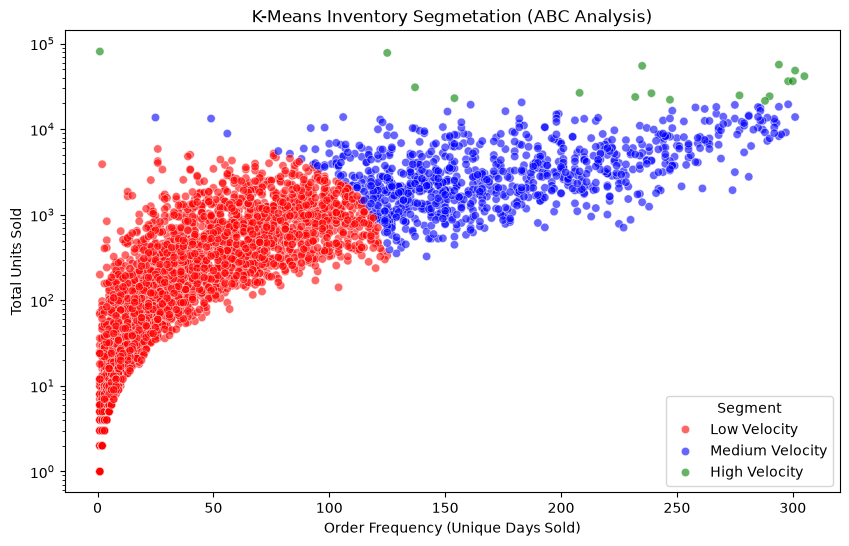

In [21]:
from sklearn.cluster import KMeans
def segment_inventory_kmeans():
    df1=df_raw.dropna(subset=["StockCode","Description","Quantity"])
    df1 = df1[df1["Quantity"] > 0]
    df1["InvoiceDate"]= pd.to_datetime(df1["InvoiceDate"])
    df1["DateOnly"] = df1["InvoiceDate"].dt.date


    sku_features= df1.groupby("StockCode").agg(
        Total_Units_Sold=("Quantity","sum")
        ,Order_Frequency=("DateOnly","nunique")
    ).reset_index()

    scaler= StandardScaler()
    scaled_features = scaler.fit_transform(sku_features[["Total_Units_Sold", "Order_Frequency"]])
    kmeans=KMeans(n_clusters=3,random_state=42,n_init=10)
    sku_features["Cluster"]=kmeans.fit_predict(scaled_features)

    cluster_means=sku_features.groupby("Cluster")["Total_Units_Sold"].mean().sort_values(ascending=False)


    cluster_mapping={
        cluster_means.index[0]: "High Velocity",
        cluster_means.index[1]: "Medium Velocity",
        cluster_means.index[2]: "Low Velocity"
    }
    sku_features["Segment"] = sku_features["Cluster"].map(cluster_mapping)

    print(f"Segment Results {sku_features["Segment"].value_counts()}")

    plt.figure(figsize=(10,6))
    sns.scatterplot(
        data=sku_features,
        x="Order_Frequency",
        y="Total_Units_Sold",
        hue="Segment",
        palette=["red","blue","green"],
        alpha=0.6
    )
    plt.title("K-Means Inventory Segmetation (ABC Analysis)")
    plt.xlabel("Order Frequency (Unique Days Sold)")
    plt.ylabel("Total Units Sold")
    plt.yscale("log")
    plt.show()

    high_velocity_skus = sku_features[sku_features["Segment"] == "High Velocity"]
    high_velocity_skus.to_csv("high_velocity_skus.csv", index=False)
    
    
if __name__ == "__main__":
    segment_inventory_kmeans()


In [45]:
# Trying the above 900 rather than 50 

top_950_data=fetch_and_prepare_data(950)

rfc=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')

def train_fmcg_new_demand_model(model,new_data=None):
    # loading_data
    if new_data is None :
        df= pd.read_csv("Sandbox_fmcg_pipeline.csv")
        
        # print(f"Loaded {len(df)} rows for modeling.")
    else:
        df=new_data
    df["Date"]=pd.to_datetime(df["Date"])
    
    # I am creating Lag and Rolling features per Region

    df["Sales_Lag_1"]=df.groupby(["Region","StockCode"])["Units_Sold"].shift(1)
    df["Sales_Lag_2"]=df.groupby(["Region", "StockCode"])["Units_Sold"].shift(2)

    # Rolling average of units sold
    df["Sales_Rolling_Mean_3"]=df.groupby(["Region","StockCode"])["Units_Sold"].transform(lambda x: x.shift(1).rolling(window=3).mean())

    # adding the yesterday's closing stock! trying to solve the Blind Warehouse Problem 
    df["Stock_Lag_1"]= df.groupby(["Region","StockCode"])["Current_Stock"].shift(1)

    df["Sales_Rolling_Mean_7"]=df.groupby(["Region", "StockCode"])["Units_Sold"].transform(lambda x: x.shift(1).rolling(window=7).mean())

    df["Day_of_Week"]= df["Date"].dt.dayofweek

    df["Target_Reorder_Next_3_Days"]= df.groupby(["Region","StockCode"])["Reorder_Triggered"].transform(
        lambda x: x.shift(-1).rolling(window=3, min_periods=1).max()
    )

    df=df.dropna().reset_index(drop=True)

    feature_cols=["Sales_Lag_1","Sales_Lag_2",'Sales_Rolling_Mean_3',"Sales_Rolling_Mean_7", "Stock_Lag_1","Day_of_Week"]

    X=df[feature_cols]
    y=df['Target_Reorder_Next_3_Days']

    df=df.sort_values("Date")
    split_idx=int(len(df) * 0.8)

    X_train,X_test=X.iloc[:split_idx],X.iloc[split_idx:]
    y_train,y_test= y.iloc[:split_idx],y.iloc[split_idx:]

    print(f"Training set size: {len(X_train)} | Test set size: {len(X_test)}")

    # Training the predictive model
    model.fit(X_train,y_train)


    y_pred=model.predict(X_test)
    print(f"EVALUATION : {classification_report(y_test,y_pred)}")


    importances = model.feature_importances_
    for name, importance in zip(feature_cols, importances):
        print(f"{name}: {importance:.4f}")

    return model
trained_model=train_fmcg_new_demand_model(model=rfc,new_data=top_950_data)
trained_model

541909 transactions.
 Engineered 184997 clean history
Training set size: 123549 | Test set size: 30888
EVALUATION :               precision    recall  f1-score   support

         0.0       0.98      0.98      0.98     28174
         1.0       0.76      0.76      0.76      2714

    accuracy                           0.96     30888
   macro avg       0.87      0.87      0.87     30888
weighted avg       0.96      0.96      0.96     30888

Sales_Lag_1: 0.0749
Sales_Lag_2: 0.0443
Sales_Rolling_Mean_3: 0.0921
Sales_Rolling_Mean_7: 0.1196
Stock_Lag_1: 0.6464
Day_of_Week: 0.0227


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.